# Crop Recommendation System Using LightGBM

## Objective
Build a multiclass machine-learning system that recommends a suitable crop from soil and environmental conditions.

**Inputs:** N, P, K, temperature, humidity, ph, rainfall  
**Target:** label (crop)

**Flow:** Data Loading → Validation → EDA → Feature/Target Definition → Stratified Split → Baselines → LightGBM → Evaluation → Cross-Validation → ROC-AUC → SHAP → Counterfactuals → Robustness → Sample Prediction → Conclusion

## 1. Environment and Imports
Install missing packages once in your environment; keep installation separate from the analysis.

In [1]:
# If required, run once:
# %pip install pandas numpy matplotlib seaborn scikit-learn lightgbm shap

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
import shap

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("images", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


c:\Users\Bhavya\Downloads\crop-recommendation-system VC\PBL_Proj\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the Dataset

In [2]:
DATA_PATH = Path("Crop_recommendation.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Place Crop_recommendation.csv in the notebook working directory."
    )

cropdf = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {cropdf.shape}")
display(cropdf.head())

Dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Initial Dataset Validation

In [3]:
print("Columns:", cropdf.columns.tolist())
print("\nData types:")
display(cropdf.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(cropdf.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", cropdf.duplicated().sum())
print("\nBasic statistics:")
display(cropdf.describe(include="all").T)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data types:


,dtype
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,str



Missing values:


,missing_values
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0



Duplicate rows: 0

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
N,2200.0,NaN,NaN,NaN,50.551818,36.917334,0.0,21.0,37.0,84.25,140.0
P,2200.0,NaN,NaN,NaN,53.362727,32.985883,5.0,28.0,51.0,68.0,145.0
K,2200.0,NaN,NaN,NaN,48.149091,50.647931,5.0,20.0,32.0,49.0,205.0
temperature,2200.0,NaN,NaN,NaN,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,NaN,NaN,NaN,71.481779,22.263812,14.25804,60.261953,80.473146,89.948771,99.981876
ph,2200.0,NaN,NaN,NaN,6.46948,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,NaN,NaN,NaN,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117
label,2200,22,rice,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Target Class Analysis

Number of crop classes: 22


,count
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


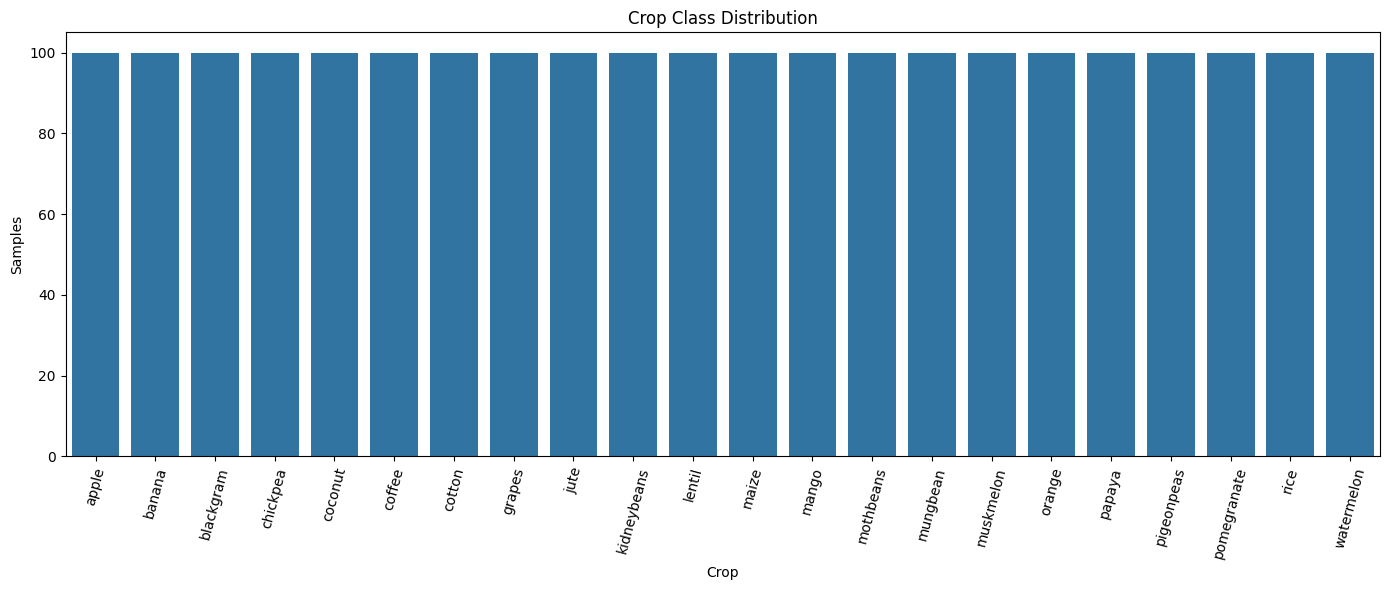

In [4]:
if "label" not in cropdf.columns:
    raise ValueError("Target column 'label' is missing.")

class_counts = cropdf["label"].value_counts().sort_index()
print("Number of crop classes:", cropdf["label"].nunique())
display(class_counts.to_frame("count"))

plt.figure(figsize=(14, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=75)
plt.xlabel("Crop")
plt.ylabel("Samples")
plt.title("Crop Class Distribution")
plt.tight_layout()
plt.savefig("images/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Required Feature Validation

In [5]:
FEATURE_COLUMNS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

missing_features = [c for c in FEATURE_COLUMNS if c not in cropdf.columns]
if missing_features:
    raise ValueError(f"Missing feature columns: {missing_features}")

if cropdf[FEATURE_COLUMNS].isnull().any().any():
    raise ValueError("Missing values found in feature columns.")

if cropdf["label"].isnull().any():
    raise ValueError("Missing values found in target.")

non_numeric = cropdf[FEATURE_COLUMNS].select_dtypes(exclude=np.number).columns.tolist()
if non_numeric:
    raise TypeError(f"Non-numeric feature columns: {non_numeric}")

print("Schema and data-type checks passed.")

Schema and data-type checks passed.


# 6. Exploratory Data Analysis
EDA is completed before model training so the dataset is understood first.

### 6.1 Crop-wise Mean Feature Summary

In [6]:
crop_summary = cropdf.groupby("label")[FEATURE_COLUMNS].mean().sort_index()
display(crop_summary)

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


### 6.2 Nitrogen (N) Analysis

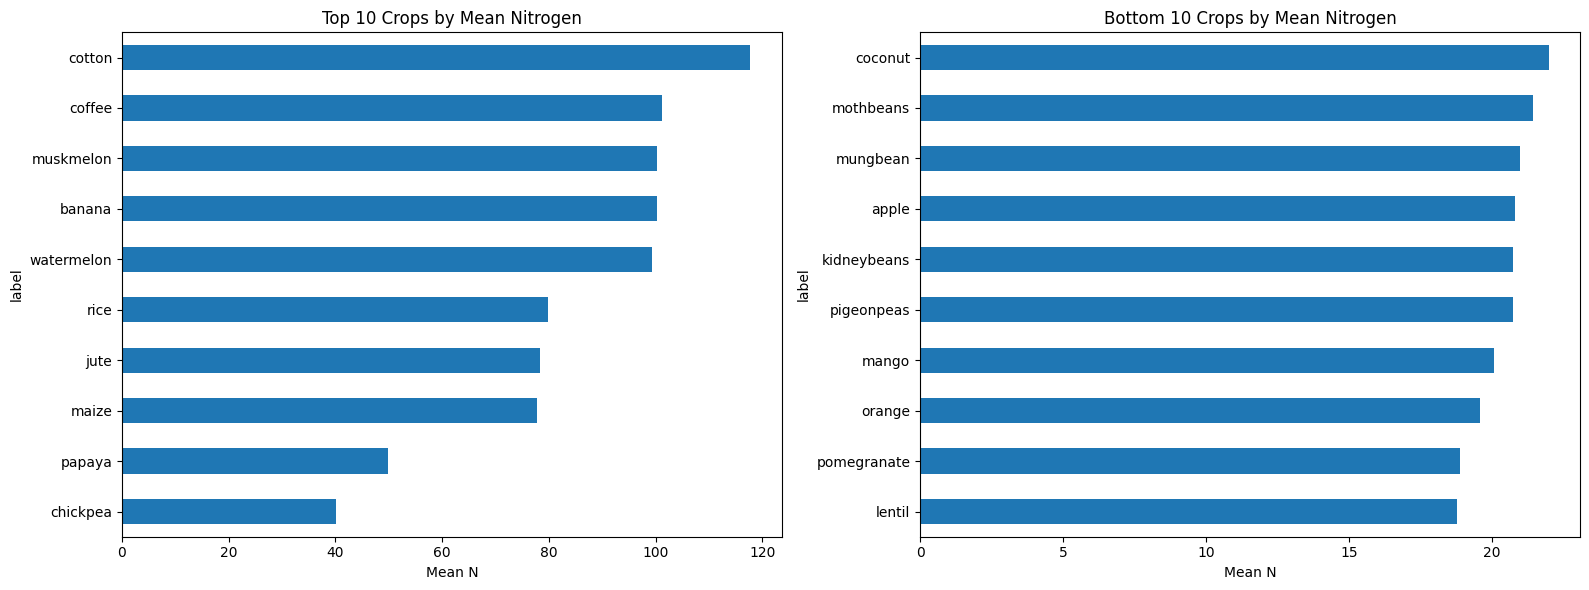

In [7]:
n_sorted = crop_summary["N"].sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
n_sorted.head(10).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 Crops by Mean Nitrogen")
axes[0].set_xlabel("Mean N")
n_sorted.tail(10).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Bottom 10 Crops by Mean Nitrogen")
axes[1].set_xlabel("Mean N")
plt.tight_layout()
plt.savefig("images/nitrogen_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.3 Phosphorus (P) Analysis

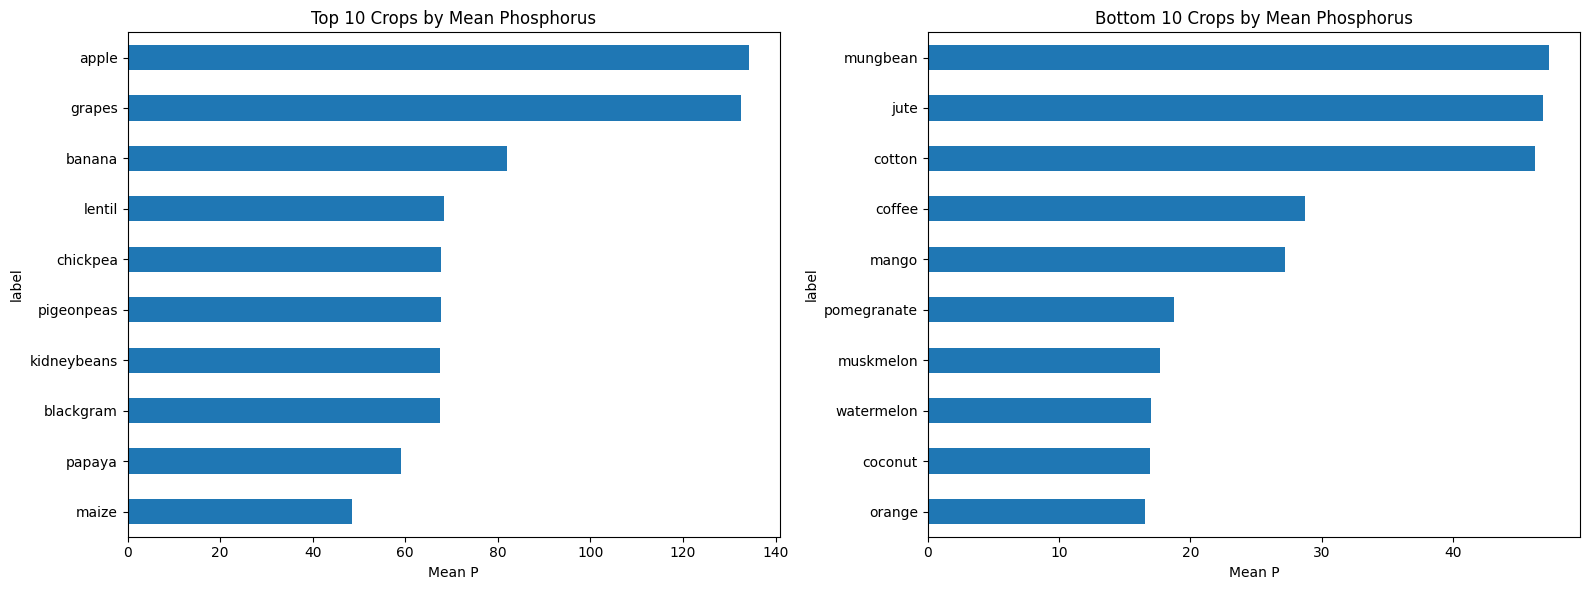

In [8]:
p_sorted = crop_summary["P"].sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
p_sorted.head(10).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 Crops by Mean Phosphorus")
axes[0].set_xlabel("Mean P")
p_sorted.tail(10).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Bottom 10 Crops by Mean Phosphorus")
axes[1].set_xlabel("Mean P")
plt.tight_layout()
plt.savefig("images/phosphorus_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.4 Potassium (K) Analysis

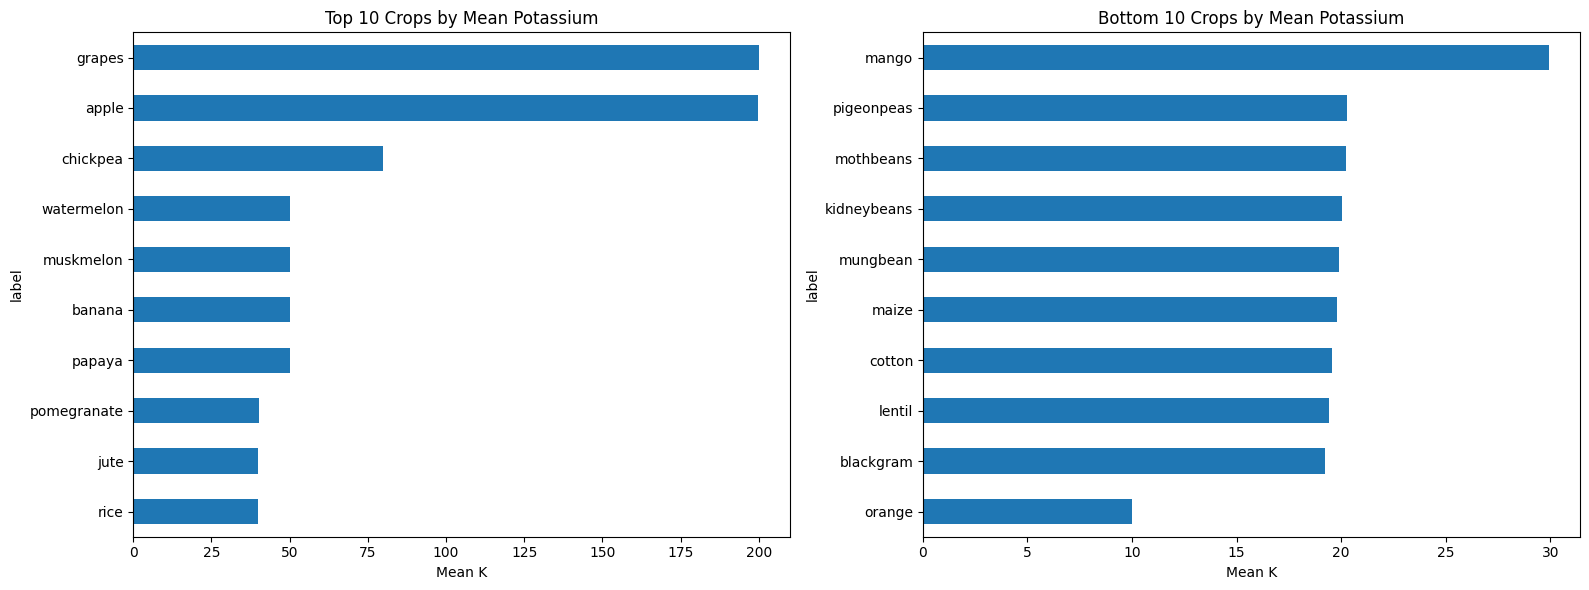

In [9]:
k_sorted = crop_summary["K"].sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
k_sorted.head(10).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 Crops by Mean Potassium")
axes[0].set_xlabel("Mean K")
k_sorted.tail(10).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Bottom 10 Crops by Mean Potassium")
axes[1].set_xlabel("Mean K")
plt.tight_layout()
plt.savefig("images/potassium_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.5 N, P and K Comparison

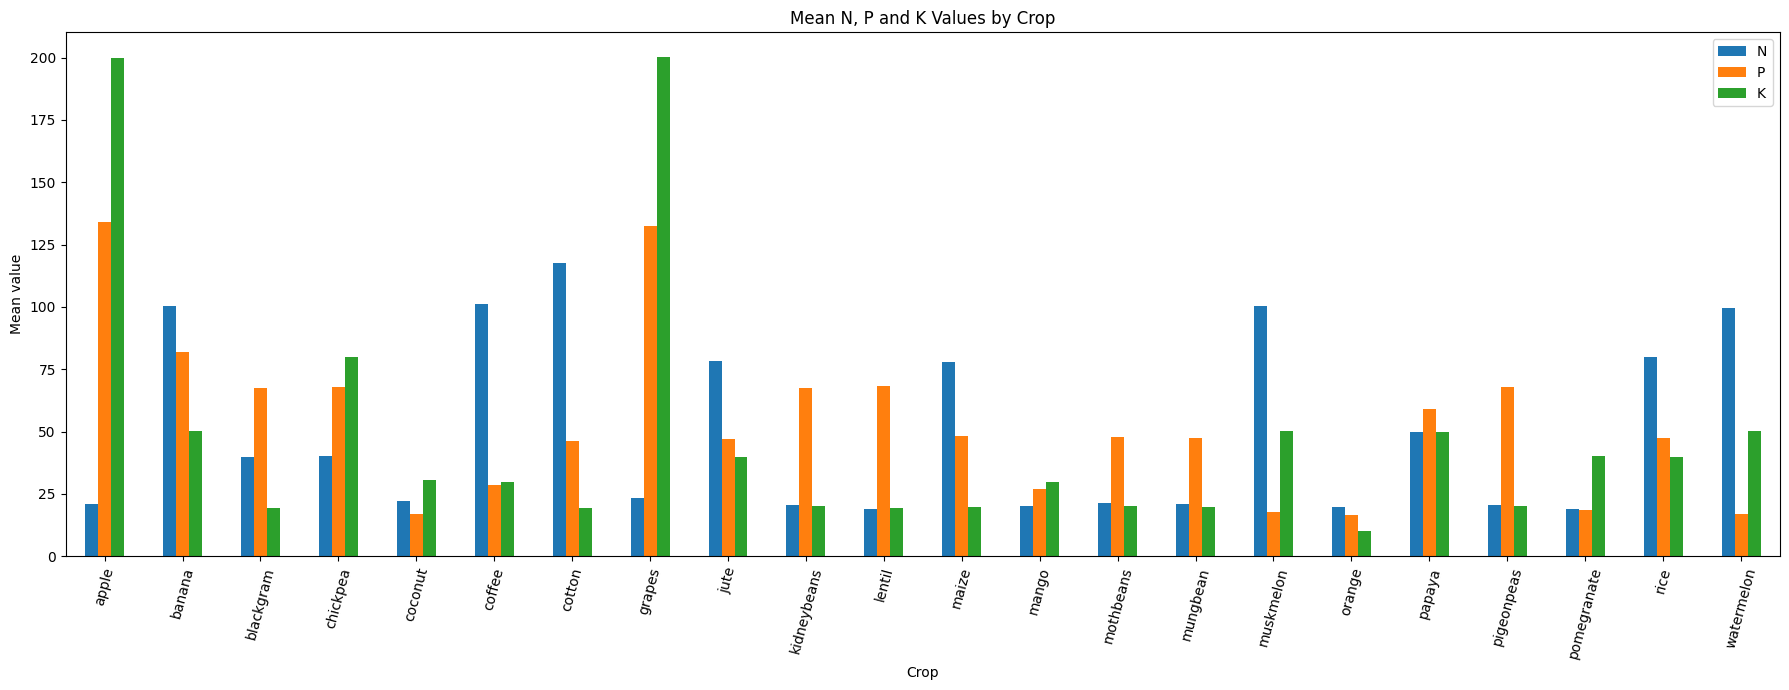

In [10]:
crop_summary[["N", "P", "K"]].plot(kind="bar", figsize=(18, 7))
plt.title("Mean N, P and K Values by Crop")
plt.xlabel("Crop")
plt.ylabel("Mean value")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("images/npk_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.6 Environmental Conditions Comparison

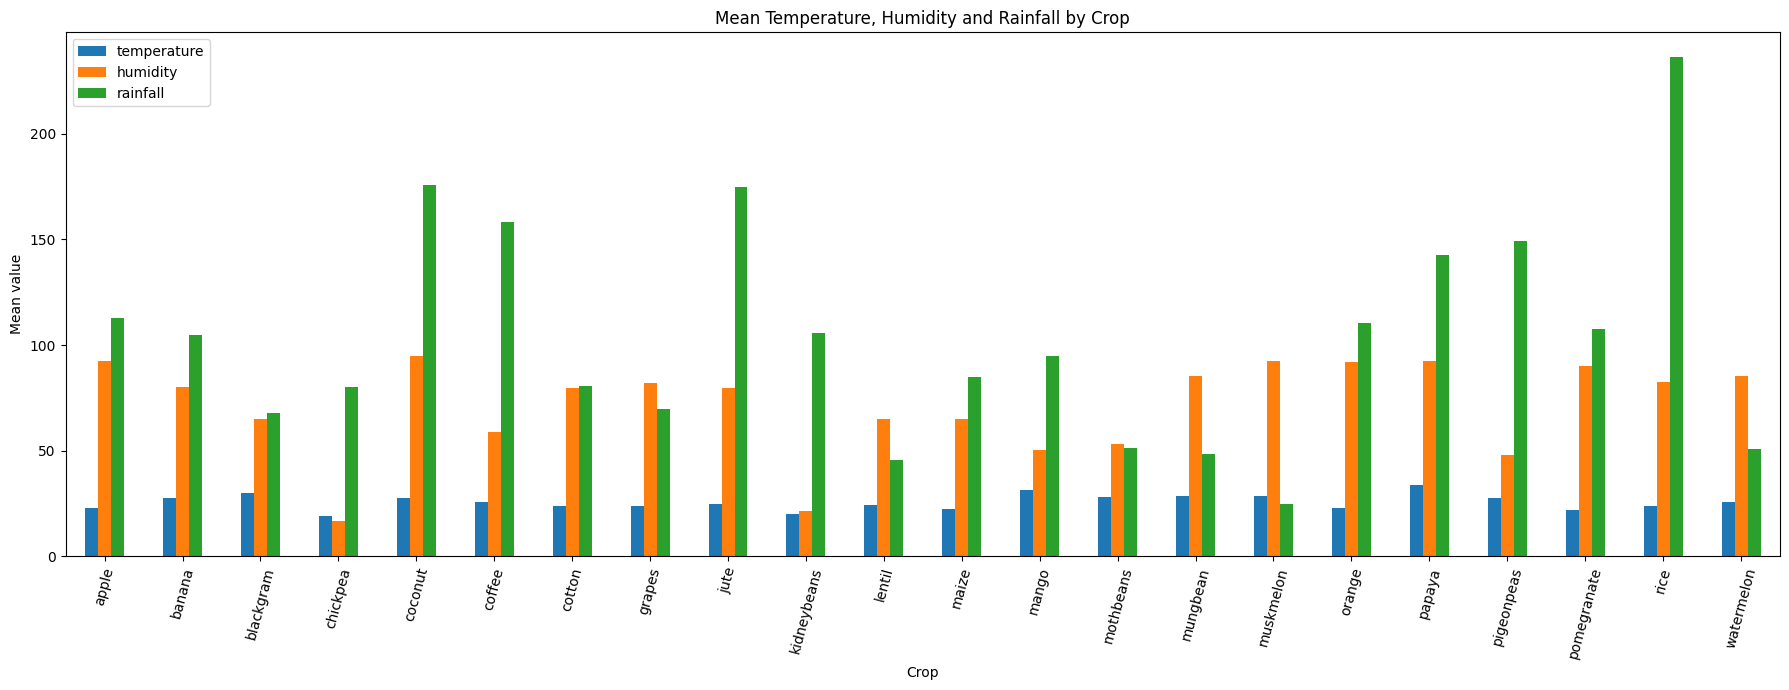

In [11]:
crop_summary[["temperature", "humidity", "rainfall"]].plot(kind="bar", figsize=(18, 7))
plt.title("Mean Temperature, Humidity and Rainfall by Crop")
plt.xlabel("Crop")
plt.ylabel("Mean value")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("images/environmental_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.7 Feature Distributions

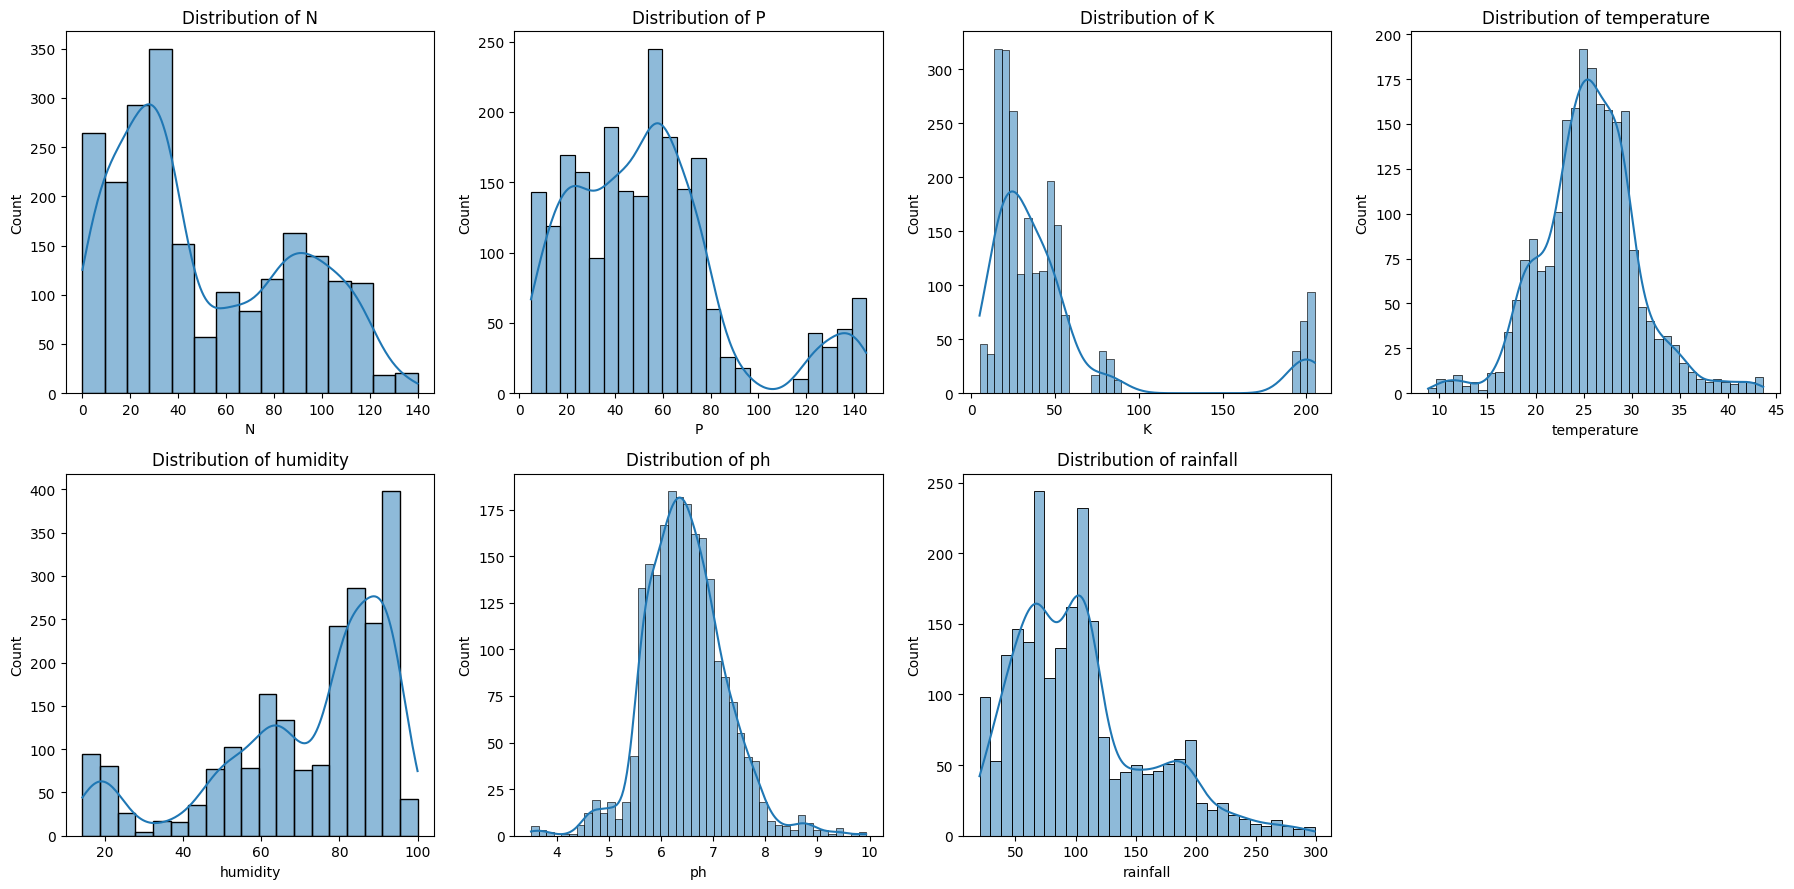

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, feature in enumerate(FEATURE_COLUMNS):
    sns.histplot(cropdf[feature], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("images/feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.8 Feature Correlation

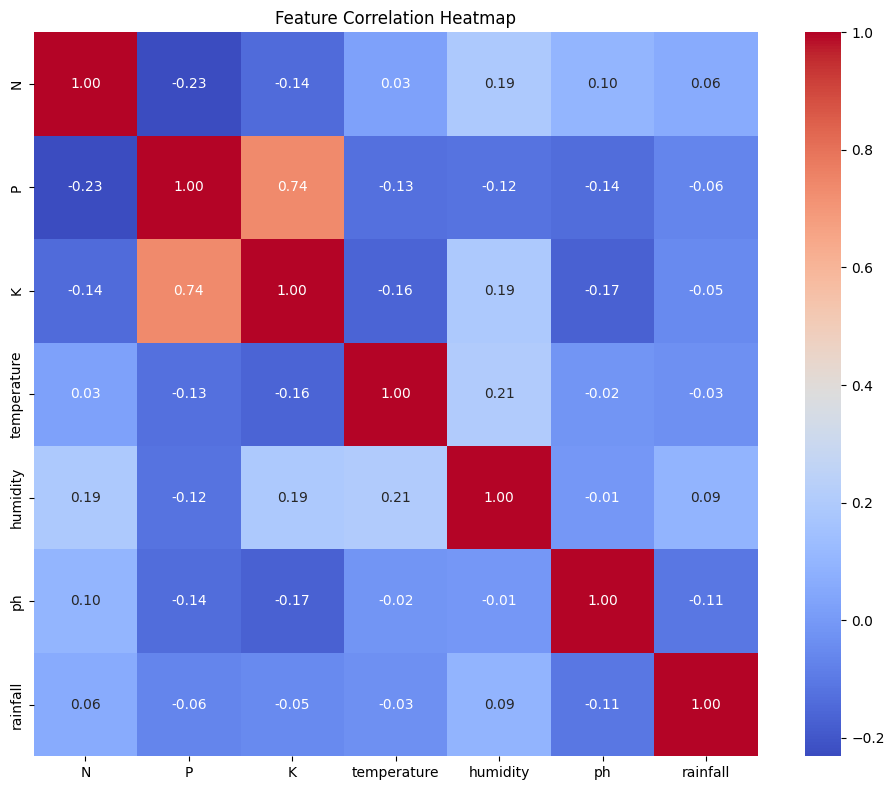

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(cropdf[FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. Feature Matrix and Target

LightGBM is tree-based, so feature scaling is not required. The final pipeline therefore uses the original feature values.

In [14]:
X = cropdf[FEATURE_COLUMNS].copy()
y = cropdf["label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (2200, 7)
y shape: (2200,)


,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


# 8. Train-Test Split

Create the split once and reuse it throughout the notebook. Stratification preserves crop proportions.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
    shuffle=True
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (1540, 7) | X_test: (660, 7)


# 9. Baseline Model Comparison

In [16]:
baseline_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    )
}

baseline_results = []
for name, clf in baseline_models.items():
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1-Score": f1_score(y_test, pred, average="macro", zero_division=0)
    })

baseline_df = (
    pd.DataFrame(baseline_results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)
display(baseline_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.995455,0.995601,0.995455,0.995453
1,Naive Bayes,0.992424,0.992935,0.992424,0.992412
2,Decision Tree,0.978788,0.979319,0.978788,0.978743
3,KNN,0.978788,0.980125,0.978788,0.978685
4,SVM,0.978788,0.981991,0.978788,0.978553


# 10. Final LightGBM Model

Use one clearly defined final model. This is the model used for all later evaluation and explainability.

In [17]:
model = LGBMClassifier(
    objective="multiclass",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)
model.fit(X_train, y_train)
print("LightGBM model trained successfully.")

LightGBM model trained successfully.


# 11. Predictions

In [18]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_proba.shape)

Prediction shape: (660,)
Probability shape: (660, 22)


# 12. Model Evaluation

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9894
Precision: 0.9900
Recall   : 0.9894
F1-Score : 0.9894


### 12.1 Training vs Testing Accuracy

In [20]:
train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")
print(f"Accuracy Gap     : {train_accuracy - test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy : 0.9894
Accuracy Gap     : 0.0106


### 12.2 Classification Report

In [21]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        30
      banana     1.0000    1.0000    1.0000        30
   blackgram     0.9677    1.0000    0.9836        30
    chickpea     1.0000    1.0000    1.0000        30
     coconut     1.0000    1.0000    1.0000        30
      coffee     1.0000    1.0000    1.0000        30
      cotton     0.9677    1.0000    0.9836        30
      grapes     1.0000    1.0000    1.0000        30
        jute     0.9355    0.9667    0.9508        30
 kidneybeans     1.0000    1.0000    1.0000        30
      lentil     1.0000    0.9333    0.9655        30
       maize     1.0000    1.0000    1.0000        30
       mango     1.0000    1.0000    1.0000        30
   mothbeans     0.9091    1.0000    0.9524        30
    mungbean     1.0000    0.9667    0.9831        30
   muskmelon     1.0000    1.0000    1.0000        30
      orange     1.0000    1.0000    1.0000        30
      papaya     1.0000    

### 12.3 Confusion Matrix

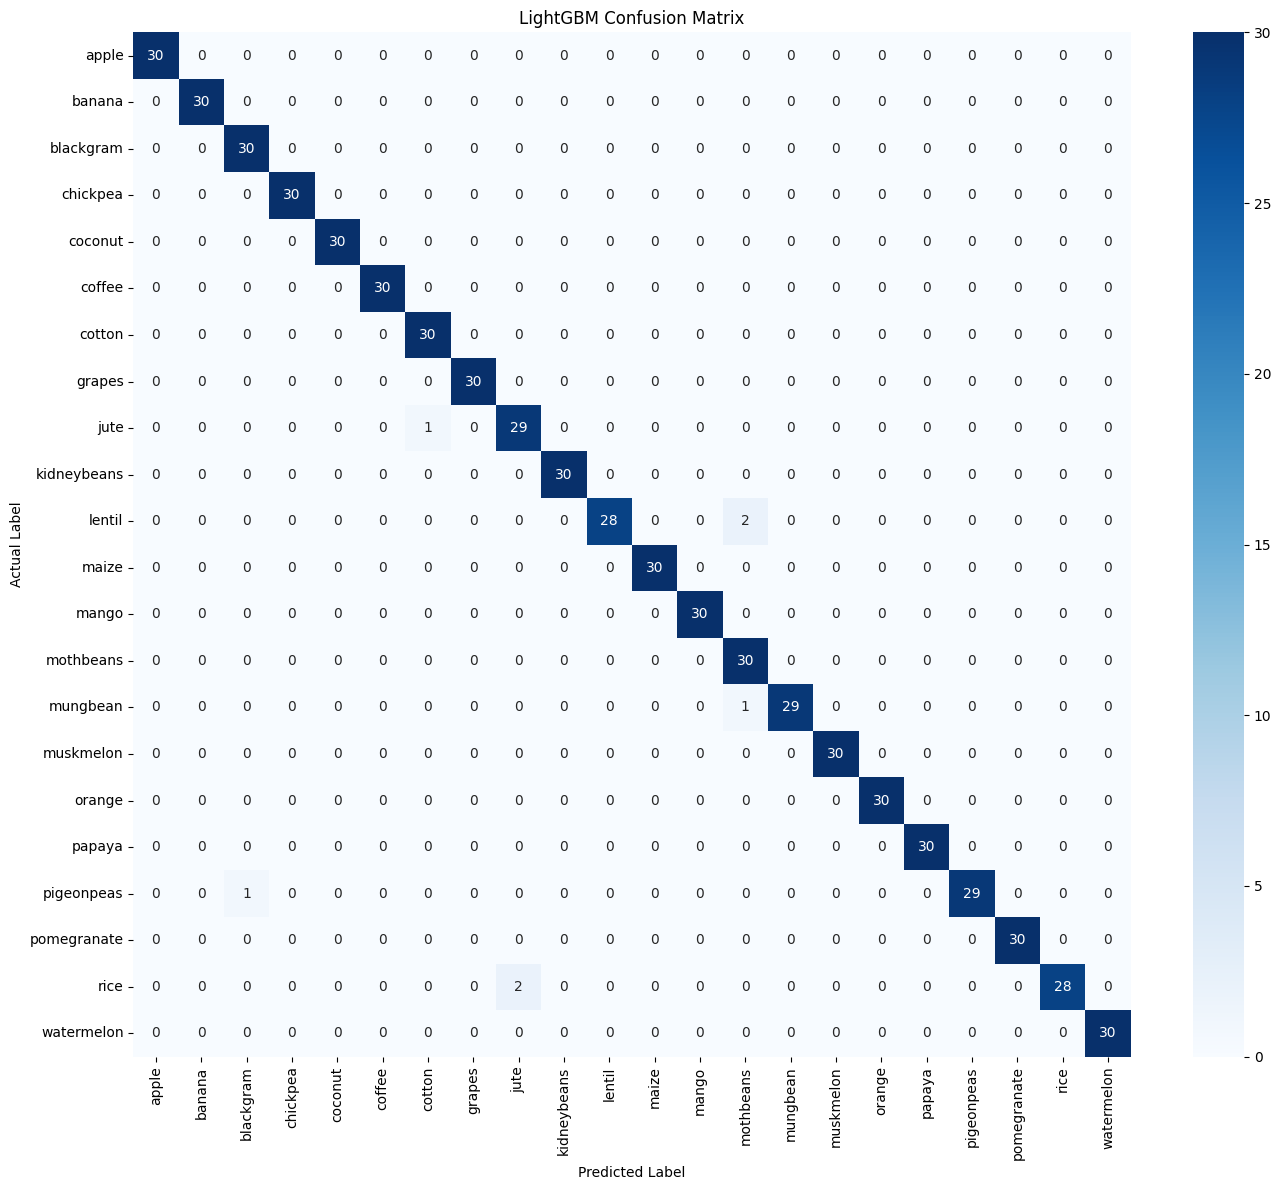

In [22]:
class_names = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("LightGBM Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### 12.4 LightGBM Feature Importance

,Feature,Importance
4,humidity,17214
6,rainfall,12930
0,N,9767
1,P,9552
2,K,7335
3,temperature,6632
5,ph,6489


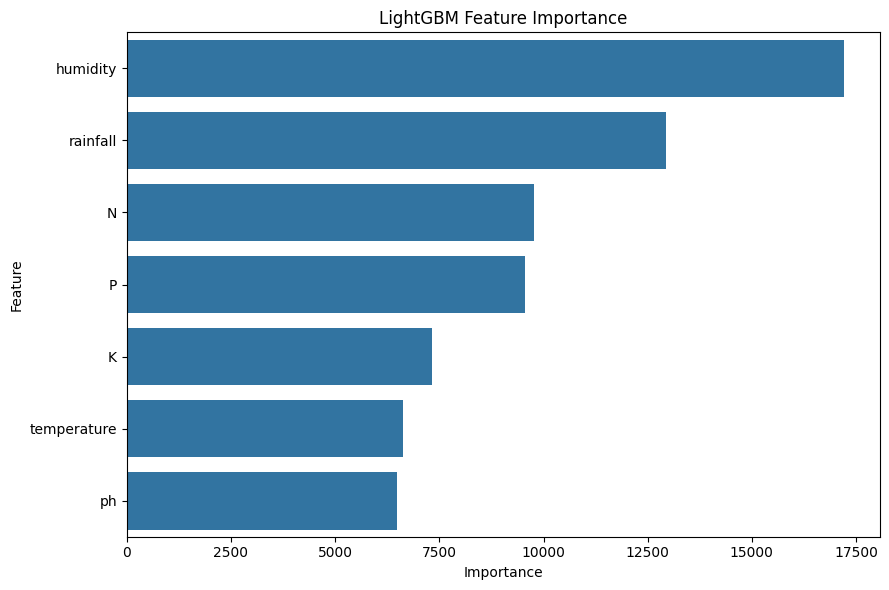

In [23]:
feature_importance = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)
display(feature_importance)

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.savefig("images/lightgbm_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# 13. 5-Fold Stratified Cross-Validation

This estimates accuracy stability across five different training/validation partitions.

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_model = LGBMClassifier(
    objective="multiclass",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

cv_scores = cross_val_score(cv_model, X, y, cv=cv, scoring="accuracy", n_jobs=1)

print("Fold accuracies:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV std. dev.   : {cv_scores.std():.4f}")

Fold accuracies: [0.9909 0.9932 0.9909 0.9955 0.9932]
Mean CV accuracy: 0.9927
CV std. dev.   : 0.0017


# 14. Multiclass ROC-AUC

Macro ROC-AUC (OvR): 1.0000


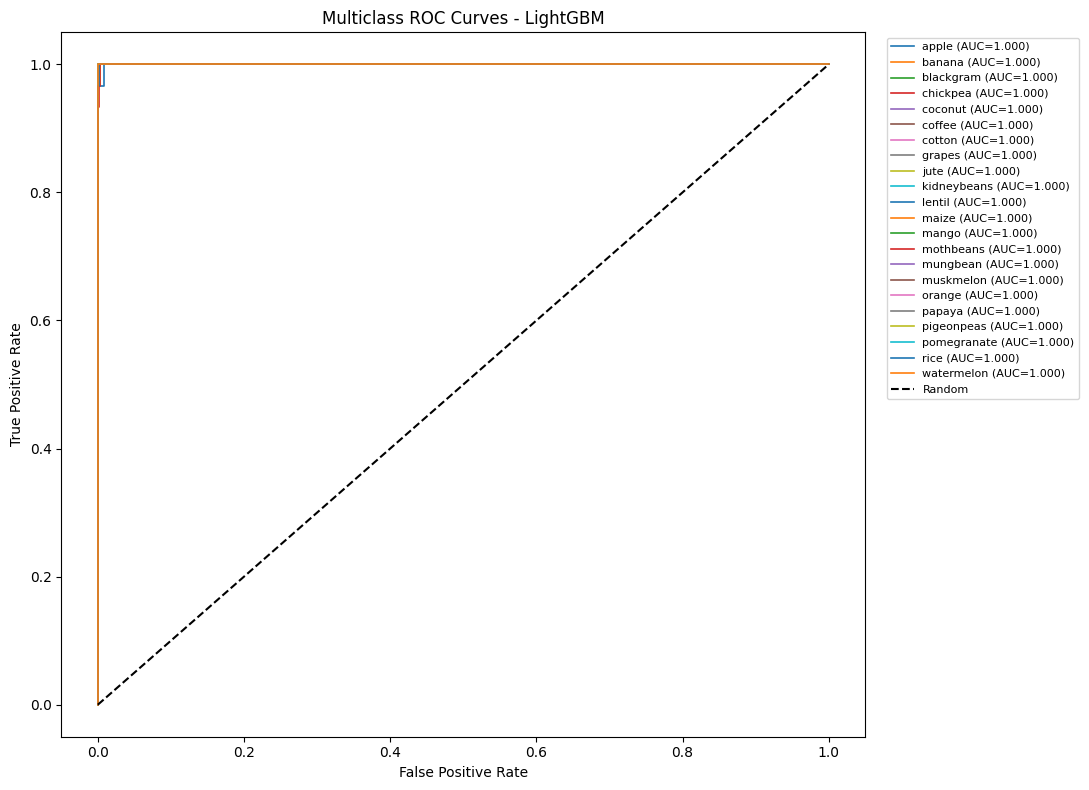

In [25]:
y_test_bin = label_binarize(y_test, classes=class_names)

roc_auc_macro = roc_auc_score(
    y_test_bin, y_proba, multi_class="ovr", average="macro"
)
print(f"Macro ROC-AUC (OvR): {roc_auc_macro:.4f}")

plt.figure(figsize=(11, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.2, label=f"{class_name} (AUC={class_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves - LightGBM")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("images/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# 15. Explainability with SHAP

Use SHAP directly on the final LightGBM model. The model is not replaced with an OvR wrapper just for explanation.

In [26]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP computation completed.")
print("SHAP type:", type(shap_values))

SHAP computation completed.
SHAP type: <class 'numpy.ndarray'>


### 15.1 Global SHAP Importance

,Feature,Mean |SHAP|
4,humidity,0.731840
6,rainfall,0.629225
1,P,0.603149
2,K,0.426099
0,N,0.425256
3,temperature,0.204465
5,ph,0.131363


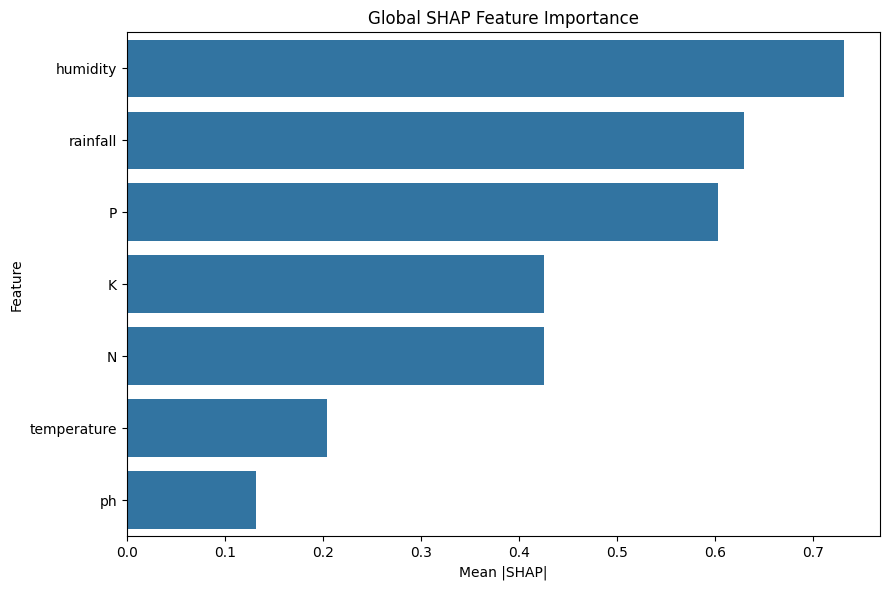

In [27]:
if isinstance(shap_values, list):
    shap_matrix = np.stack([np.asarray(v) for v in shap_values], axis=0)
    global_shap = np.mean(np.abs(shap_matrix), axis=(0, 1))
else:
    arr = np.asarray(shap_values)
    if arr.ndim == 3:
        global_shap = np.mean(np.abs(arr), axis=(0, 2))
    else:
        global_shap = np.mean(np.abs(arr), axis=0)

global_shap_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Mean |SHAP|": global_shap
}).sort_values("Mean |SHAP|", ascending=False)

display(global_shap_df)

plt.figure(figsize=(9, 6))
sns.barplot(data=global_shap_df, x="Mean |SHAP|", y="Feature")
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.savefig("images/feature_importance_shap.png", dpi=300, bbox_inches="tight")
plt.show()

### 15.2 Local SHAP Explanation

In [28]:
sample_position = 0
sample_input = X_test.iloc[[sample_position]]
sample_actual = y_test.iloc[sample_position]
sample_prediction = model.predict(sample_input)[0]

predicted_class_index = list(model.classes_).index(sample_prediction)

if isinstance(shap_values, list):
    local_values = np.asarray(shap_values[predicted_class_index][sample_position])
    base_value = np.asarray(explainer.expected_value)[predicted_class_index]
else:
    arr = np.asarray(shap_values)
    if arr.ndim == 3:
        local_values = arr[sample_position, :, predicted_class_index]
        base_value = np.asarray(explainer.expected_value)[predicted_class_index]
    else:
        local_values = arr[sample_position]
        base_value = np.asarray(explainer.expected_value).reshape(-1)[0]

local_explanation = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Feature Value": sample_input.iloc[0].values,
    "SHAP Contribution": local_values
}).sort_values(
    "SHAP Contribution",
    key=lambda s: np.abs(s),
    ascending=False
)

print("Actual crop   :", sample_actual)
print("Predicted crop:", sample_prediction)
display(local_explanation)

Actual crop   : kidneybeans
Predicted crop: kidneybeans


,Feature,Feature Value,SHAP Contribution
4,humidity,22.743790,10.038496
2,K,22.000000,1.963862
5,ph,5.940547,1.519546
0,N,11.000000,0.576564
3,temperature,23.897568,0.320129
6,rainfall,112.661643,0.081152
1,P,78.000000,0.002345


# 16. Counterfactual / What-If Analysis

We vary one feature while holding the other six fixed. This is an exploratory model-sensitivity tool, not proof that changing one real-world agricultural condition alone guarantees a different crop outcome.

In [29]:
def generate_counterfactuals(input_sample, model, feature_name, value_range):
    if feature_name not in input_sample.columns:
        raise ValueError(f"Unknown feature: {feature_name}")

    original_prediction = model.predict(input_sample)[0]
    rows = []

    for value in value_range:
        modified = input_sample.copy()
        modified.loc[:, feature_name] = value
        prediction = model.predict(modified)[0]
        rows.append({
            feature_name: value,
            "Prediction": prediction,
            "Changed": prediction != original_prediction
        })

    return pd.DataFrame(rows), original_prediction

print("Function defined.")

Function defined.


### 16.1 Rainfall Scenario

In [30]:
rainfall_range = np.linspace(
    X_train["rainfall"].min(),
    X_train["rainfall"].max(),
    25
)
rainfall_cf, original_prediction = generate_counterfactuals(
    sample_input, model, "rainfall", rainfall_range
)
print("Original prediction:", original_prediction)
display(rainfall_cf)

Original prediction: kidneybeans


,rainfall,Prediction,Changed
0,20.211267,muskmelon,True
1,31.809136,kidneybeans,False
2,43.407005,kidneybeans,False
3,55.004874,kidneybeans,False
4,66.602742,kidneybeans,False
5,78.200611,kidneybeans,False
6,89.798480,kidneybeans,False
7,101.396349,kidneybeans,False
8,112.994217,kidneybeans,False
9,124.592086,kidneybeans,False


### 16.2 Potassium (K) Scenario

In [31]:
potassium_range = np.linspace(
    X_train["K"].min(),
    X_train["K"].max(),
    25
)
def generate_counterfactuals(input_sample, model, feature_name, value_range):
    """
    Generate predictions by varying one feature while keeping
    all other features constant.
    """

    # Always work with float values for counterfactual analysis
    modified_base = input_sample.copy().astype(float)

    rows = []

    for value in value_range:
        modified = modified_base.copy()

        # Set the feature to the counterfactual value
        modified.loc[:, feature_name] = float(value)

        # Predict
        prediction = model.predict(modified)[0]

        rows.append({
            feature_name: value,
            "Predicted Crop": prediction
        })

    original_prediction = model.predict(input_sample)[0]

    return pd.DataFrame(rows), original_prediction

# 17. Robustness to Input Noise

The original notebook clipped raw data to `[0,1]`, which is inappropriate here because the features are on different physical scales. Instead, we add noise relative to each feature's training standard deviation and clip to the observed training range.

,Noise Level,Mean Accuracy,Std Accuracy
0,0.00,0.989394,1.110223e-16
1,0.01,0.986424,2.385293e-03
2,0.05,0.949697,7.453560e-03
3,0.10,0.897303,1.183096e-02


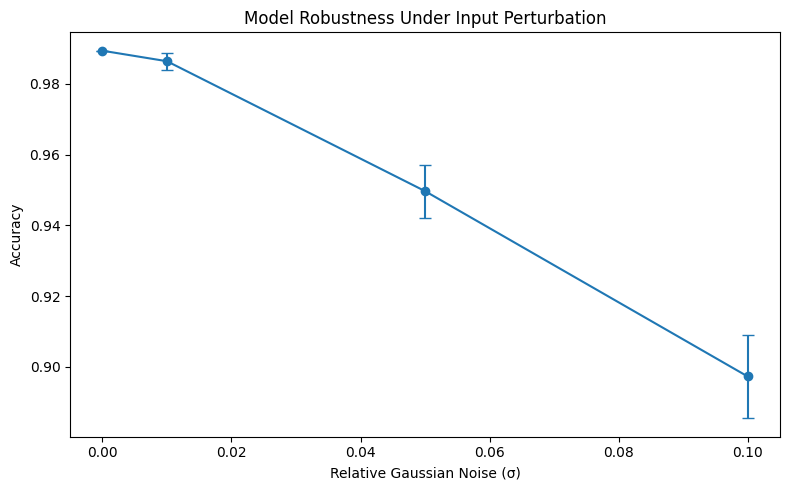

In [32]:
def evaluate_noise_robustness(model, X_test, y_test, X_train,
                             noise_levels=(0.00, 0.01, 0.05, 0.10),
                             repeats=50):
    feature_std = X_train.std(axis=0).replace(0, 1)
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    rng = np.random.default_rng(RANDOM_STATE)
    results = []

    for sigma in noise_levels:
        accuracies = []

        for _ in range(repeats):
            noise = rng.normal(0, sigma, size=X_test.shape)
            noisy = X_test + noise * feature_std.values
            noisy = pd.DataFrame(noisy, columns=X_test.columns, index=X_test.index)
            noisy = noisy.clip(lower=train_min, upper=train_max, axis="columns")

            pred = model.predict(noisy)
            accuracies.append(accuracy_score(y_test, pred))

        results.append({
            "Noise Level": sigma,
            "Mean Accuracy": np.mean(accuracies),
            "Std Accuracy": np.std(accuracies)
        })

    return pd.DataFrame(results)

noise_results = evaluate_noise_robustness(model, X_test, y_test, X_train)
display(noise_results)

plt.figure(figsize=(8, 5))
plt.errorbar(
    noise_results["Noise Level"],
    noise_results["Mean Accuracy"],
    yerr=noise_results["Std Accuracy"],
    marker="o",
    capsize=4
)
plt.xlabel("Relative Gaussian Noise (σ)")
plt.ylabel("Accuracy")
plt.title("Model Robustness Under Input Perturbation")
plt.tight_layout()
plt.savefig("images/noise_robustness.png", dpi=300, bbox_inches="tight")
plt.show()

# 18. New Sample Prediction

Feature order: **N, P, K, temperature, humidity, ph, rainfall**.

In [33]:
example_input = pd.DataFrame(
    [[90, 42, 43, 20.879744, 75, 5.5, 220]],
    columns=FEATURE_COLUMNS
)

predicted_crop = model.predict(example_input)[0]
probabilities = model.predict_proba(example_input)[0]

prediction_table = pd.DataFrame({
    "Crop": model.classes_,
    "Probability": probabilities
}).sort_values("Probability", ascending=False).reset_index(drop=True)

print("Recommended crop:", predicted_crop)
display(prediction_table.head(5))

Recommended crop: rice


,Crop,Probability
0,rice,0.996940
1,jute,0.001293
2,kidneybeans,0.000205
3,banana,0.000137
4,coffee,0.000124


# 19. Final Results Summary

In [34]:
summary_table = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Macro ROC-AUC",
        "Mean 5-Fold CV Accuracy",
        "CV Accuracy Std"
    ],
    "Value": [
        accuracy, precision, recall, f1,
        roc_auc_macro, cv_scores.mean(), cv_scores.std()
    ]
})
display(summary_table)

,Metric,Value
0,Test Accuracy,0.989394
1,Macro Precision,0.990003
2,Macro Recall,0.989394
3,Macro F1,0.989434
4,Macro ROC-AUC,0.999974
5,Mean 5-Fold CV Accuracy,0.992727
6,CV Accuracy Std,0.001701


# 20. Conclusion

The notebook now follows one connected pipeline:

1. Dataset loading and validation
2. Class and data-quality analysis
3. Soil/environmental EDA
4. Feature-target definition
5. One stratified train/test split
6. Baseline model comparison
7. One final LightGBM model
8. Consistent evaluation
9. Cross-validation
10. Multiclass ROC-AUC
11. SHAP global and local explainability
12. Counterfactual what-if analysis
13. Robustness testing
14. New-input crop recommendation

The final `model`, `X_train`, `X_test`, `y_train`, `y_test`, `y_pred`, and `y_proba` variables remain consistent throughout the notebook.